# 01. CV 구종 그룹 분류기 — 학습·검증

`scripts/build_pitch_group_dataset.py`가 생성한 `output/pitch_type_cv/dataset.csv`로
궤적 기반 3그룹(FASTBALL/BREAKING/OFFSPEED) 분류기를 학습하고, 홀드아웃 경기로 검증한다.

**성공 기준: 최빈값 기준선(항상 최다 클래스로 찍기)을 유의미하게 상회하는지.**

랜덤 베이스라인 33%를 쓰면 안 된다. 실측 클래스 분포가 115/103/14로 불균형이라
아무것도 학습하지 않고 항상 FASTBALL만 찍어도 49.6%가 나온다. 33%를 기준으로 삼으면
51.7%짜리 무신호 모델을 성공으로 오판한다 (TS-014에서 실제로 벌어진 일).

In [ ]:
import json
import os
import sys

ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(ROOT, "src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pitch_type_cv.group_classifier import predict_group, save_classifier, train_classifier
from pitch_type_cv.trajectory_features import FEATURE_COLUMNS

# 한글 라벨이 네모(tofu)로 깨지는 것을 막는다 (TS-004). macOS 기본 탑재 폰트를 쓰고,
# 음수 부호가 깨지지 않도록 unicode_minus도 끈다.
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 경로 B(Savant 투구별 클립) 산출물. OCR 경로의 dataset.csv와 스키마가 다르다 —
# 궤적을 못 잡은 투구도 행으로 남아 있고(has_trajectory=False), play_id/pitch_type이 붙는다.
DATASET_PATH = os.path.join(ROOT, "output", "pitch_type_cv", "dataset_clips.csv")
OUT_DIR = os.path.join(ROOT, "output", "pitch_type_cv")

# all_pitches가 선택 편향의 분모다. 학습·평가에는 궤적이 잡힌 행만 쓴다.
all_pitches = pd.read_csv(DATASET_PATH)
df = all_pitches[all_pitches["has_trajectory"]].reset_index(drop=True)

print(f"전체 투구 {len(all_pitches)}개 중 궤적 확보 {len(df)}개 "
      f"({len(df) / len(all_pitches):.1%})")
print(f"경기 {all_pitches['game_pk'].nunique()}개: {sorted(all_pitches['game_pk'].unique())}")
df["group"].value_counts()

## 홀드아웃 경기 분리

`game_pk` 중 하나를 통째로 홀드아웃으로 뺀다 (경기 내 데이터 누수를 막기 위해 투구 단위가 아닌
경기 단위로 분리).

In [ ]:
game_pks = sorted(df["game_pk"].unique())

# 경기가 1개뿐이면 game_pk 홀드아웃이 불가능하다 (학습셋이 빈다).
# 그 경우 투구 단위 층화 분할로 폴백하되, 같은 경기·같은 투수의 투구가 양쪽에
# 들어가므로 결과는 "누수 허용 상한"이지 일반화 성능이 아니다.
SINGLE_GAME = len(game_pks) == 1

# 홀드아웃 경기를 명시적으로 고른다. 813027은 OFFSPEED 비율이 12.2%로 4경기 중 중간이라
# 홀드아웃이 특정 구종에 치우치지 않는다. OFFSPEED가 가장 많은 813026(29.3%)을 빼면
# 학습셋의 OFFSPEED가 얇아지고, 가장 적은 775294(7.9%)를 빼면 홀드아웃 OFFSPEED가
# 다시 몇 개 수준으로 떨어진다 — 지난 측정에서 f1이 0.00이었던 원인이다.
PREFERRED_HOLDOUT_GAME_PK = 813027

if SINGLE_GAME:
    from sklearn.model_selection import train_test_split

    print(f"경고: 경기가 1개({game_pks[0]})뿐이라 경기 단위 홀드아웃이 불가능합니다.")
    print("      투구 단위 층화 분할로 대체합니다 — 이 수치는 누수 허용 상한입니다.")
    holdout_game_pk = game_pks[0]
    train_df, holdout_df = train_test_split(
        df, test_size=0.3, stratify=df["group"], random_state=42
    )
    train_df = train_df.reset_index(drop=True)
    holdout_df = holdout_df.reset_index(drop=True)
else:
    holdout_game_pk = (
        PREFERRED_HOLDOUT_GAME_PK if PREFERRED_HOLDOUT_GAME_PK in game_pks else game_pks[-1]
    )
    print(f"홀드아웃 경기: {holdout_game_pk} (전체 {len(game_pks)}경기 중)")
    train_df = df[df["game_pk"] != holdout_game_pk].reset_index(drop=True)
    holdout_df = df[df["game_pk"] == holdout_game_pk].reset_index(drop=True)

print(f"학습 샘플: {len(train_df)}  홀드아웃 샘플: {len(holdout_df)}")
print("\n홀드아웃 그룹별 샘플 수:")
print(holdout_df["group"].value_counts().to_string())

In [3]:
model = train_classifier(train_df[FEATURE_COLUMNS + ["group"]], train_df["group"].tolist())

y_true = holdout_df["group"].tolist()
y_pred = [predict_group(model, row.to_dict())[0] for _, row in holdout_df[FEATURE_COLUMNS].iterrows()]

accuracy = accuracy_score(y_true, y_pred)

# 최빈값 기준선: 학습셋의 최다 클래스를 홀드아웃 전체에 찍었을 때의 정확도.
# 아무것도 학습하지 않은 모델이 받는 점수이므로, 이걸 못 넘으면 신호가 없는 것이다.
majority_group = train_df["group"].value_counts().idxmax()
baseline = accuracy_score(y_true, [majority_group] * len(y_true))

print(f"홀드아웃 정확도 : {accuracy:.3f}")
print(f"최빈값 기준선   : {baseline:.3f}  (항상 {majority_group})")
print(f"기준선 대비     : {accuracy - baseline:+.3f}")
print()
print(classification_report(y_true, y_pred, zero_division=0))

홀드아웃 정확도 : 0.612
최빈값 기준선   : 0.510  (항상 BREAKING)
기준선 대비     : +0.102

              precision    recall  f1-score   support

    BREAKING       0.67      0.72      0.69        25
    FASTBALL       0.60      0.60      0.60        20
    OFFSPEED       0.00      0.00      0.00         4

    accuracy                           0.61        49
   macro avg       0.42      0.44      0.43        49
weighted avg       0.59      0.61      0.60        49



## 혼동행렬 & 그룹별 정확도 시각화

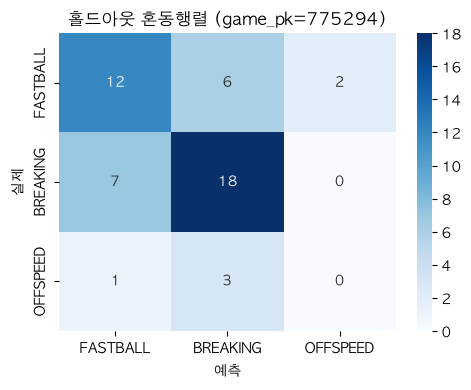

In [4]:
os.makedirs(OUT_DIR, exist_ok=True)
labels = ["FASTBALL", "BREAKING", "OFFSPEED"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title(f"홀드아웃 혼동행렬 (game_pk={holdout_game_pk})")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
# 그룹별 one-vs-rest AUC — 소수 클래스 판정은 정확도가 아니라 이 값으로 한다.
#
# 정확도와 f1은 클래스 가중치·임계값으로도 움직인다. 그래서 '특징이 정보를 넣었나'와
# '결정 규칙이 동작점을 옮겼나'가 섞인다. AUC는 순위만 보므로 그 둘을 갈라준다.
#
# 실제로 이 구분이 결정적이었다(TS-023). 좌표 특징 7개를 추가했을 때 전체 정확도는
# 0.587 -> 0.673으로 올랐지만, OFFSPEED AUC는 0.641 -> 0.648로 제자리였다.
# 오른 것은 FASTBALL(0.792 -> 0.851)과 BREAKING(0.725 -> 0.819)이었다.
from sklearn.metrics import roc_auc_score

proba = model.predict_proba(holdout_df[FEATURE_COLUMNS])
auc_by_group = {
    label: roc_auc_score(
        (pd.Series(y_true) == label).astype(int),
        proba[:, list(model.classes_).index(label)],
    )
    for label in labels
}

for label, auc in auc_by_group.items():
    n = sum(1 for g in y_true if g == label)
    print(f"{label:9s} one-vs-rest AUC = {auc:.3f}   (n={n})")
print()
print("0.5 = 무신호. OFFSPEED가 0.65 부근에 머물면 궤적에 그 구종을 가르는 정보가 없는 것이다 —")
print("이때 f1을 올리려면 클래스 가중치를 쓰는 수밖에 없고, 그건 전체 정확도를 그만큼 반납한다.")


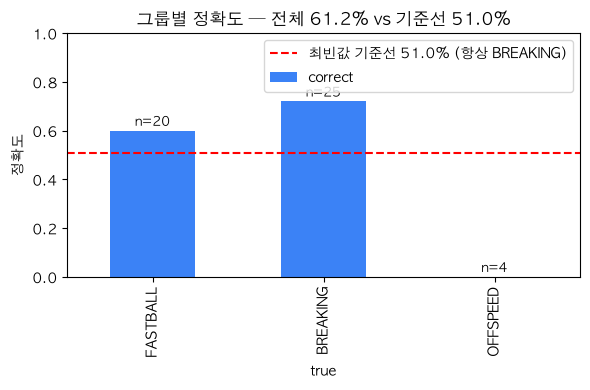

In [5]:
per_group_acc = (
    pd.DataFrame({"true": y_true, "pred": y_pred})
    .assign(correct=lambda d: d["true"] == d["pred"])
    .groupby("true")["correct"].mean()
    .reindex(labels)
)
group_counts = pd.Series(y_true).value_counts().reindex(labels).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(6, 4))
per_group_acc.plot(kind="bar", ax=ax, color="#3b82f6")
ax.axhline(baseline, color="red", linestyle="--",
           label=f"최빈값 기준선 {baseline:.1%} (항상 {majority_group})")
ax.set_ylabel("정확도")
ax.set_ylim(0, 1)
ax.set_title(f"그룹별 정확도 — 전체 {accuracy:.1%} vs 기준선 {baseline:.1%}")

# 표본이 적은 그룹의 정확도는 신뢰할 수 없으므로 n을 막대 위에 같이 적는다.
for i, label in enumerate(labels):
    value = per_group_acc.get(label)
    if pd.notna(value):
        ax.text(i, value + 0.02, f"n={group_counts[label]}", ha="center", fontsize=9)

ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "group_accuracy.png"), dpi=150)
plt.show()

In [6]:
model_path = os.path.join(OUT_DIR, "group_classifier.pkl")
save_classifier(model, model_path)
print(f"모델 저장 완료: {model_path}")

모델 저장 완료: /Users/tina/Project/baseball-pitch-predictor/output/pitch_type_cv/group_classifier.pkl


## 신호가 진짜인지 확인

정확도가 기준선을 넘었다는 것만으로는 부족하다. 아래 넷을 함께 봐야 한다.

1. **그룹별 one-vs-rest AUC** — 소수 클래스(OFFSPEED)를 겨냥한 작업은 전체 정확도로
   판정하면 안 된다. 홀드아웃 300개 중 OFFSPEED는 40개라, 40개를 전부 틀려도 전체
   정확도는 별로 안 떨어진다. AUC는 임계값·클래스 가중치와 무관해서 "정보가 늘었나"와
   "동작점을 옮겼나"를 갈라준다 (TS-023에서 이 구분이 유일한 단서였다).
2. **특징 중요도** — TS-014에서 7개 특징이 0.13~0.16으로 평평했고, 그게 감지기가 공이
   아니라 글러브를 보고 있다는 유일한 단서였다. 정확도와 무관하게 중요도가 평평하면 무신호다.
3. **순열 검정** — 표본이 작으면 우연히 기준선을 넘을 수 있다. 라벨을 섞어 학습했을 때의
   정확도 분포와 비교한다.
4. **선택 편향** — 궤적이 확보된 투구가 무작위가 아니면, 성능이 궤적 덕분인지 "잡히는 투구"의
   특성 덕분인지 구분되지 않는다.


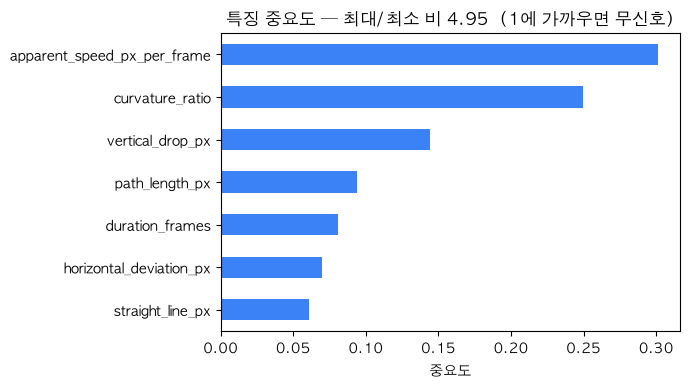

apparent_speed_px_per_frame    0.301284
curvature_ratio                0.249725
vertical_drop_px               0.143866
path_length_px                 0.093896
duration_frames                0.080466
horizontal_deviation_px        0.069926
straight_line_px               0.060837

최대/최소 비: 4.95
TS-014 당시에는 0.13~0.16으로 비가 1.23이었고, 그때 모델은 공이 아니라 글러브를 보고 있었다.


In [7]:
import numpy as np

importances = pd.Series(
    model.feature_importances_, index=FEATURE_COLUMNS
).sort_values(ascending=False)
spread = importances.max() / importances.min()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="#3b82f6")
ax.invert_yaxis()
ax.set_xlabel("중요도")
ax.set_title(f"특징 중요도 — 최대/최소 비 {spread:.2f}  (1에 가까우면 무신호)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "feature_importance.png"), dpi=150)
plt.show()

print(importances.to_string())
print(f"\n최대/최소 비: {spread:.2f}")
print("TS-014 당시에는 0.13~0.16으로 비가 1.23이었고, 그때 모델은 공이 아니라 글러브를 보고 있었다.")

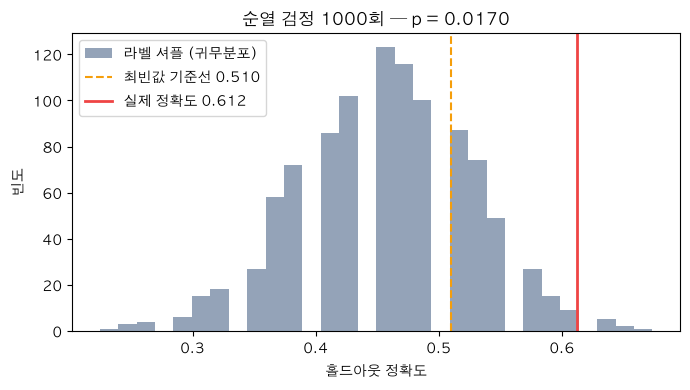

실제 정확도   : 0.612
셔플 평균     : 0.456  (95%tile 0.571)
p-value       : 0.0170  -> 유의함


In [8]:
N_PERMUTATIONS = 1000
rng = np.random.default_rng(0)

null_scores = []
for _ in range(N_PERMUTATIONS):
    shuffled = rng.permutation(train_df["group"].values)
    null_model = train_classifier(
        train_df[FEATURE_COLUMNS].assign(group=shuffled), list(shuffled)
    )
    null_pred = [
        predict_group(null_model, row.to_dict())[0]
        for _, row in holdout_df[FEATURE_COLUMNS].iterrows()
    ]
    null_scores.append(accuracy_score(y_true, null_pred))

null_scores = np.array(null_scores)
p_value = (null_scores >= accuracy).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_scores, bins=30, color="#94a3b8", label="라벨 셔플 (귀무분포)")
ax.axvline(baseline, color="#f59e0b", linestyle="--", label=f"최빈값 기준선 {baseline:.3f}")
ax.axvline(accuracy, color="#ef4444", linewidth=2, label=f"실제 정확도 {accuracy:.3f}")
ax.set_xlabel("홀드아웃 정확도")
ax.set_ylabel("빈도")
ax.set_title(f"순열 검정 {N_PERMUTATIONS}회 — p = {p_value:.4f}")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "permutation_test.png"), dpi=150)
plt.show()

print(f"실제 정확도   : {accuracy:.3f}")
print(f"셔플 평균     : {null_scores.mean():.3f}  (95%tile {np.percentile(null_scores, 95):.3f})")
print(f"p-value       : {p_value:.4f}  -> {'유의함' if p_value < 0.05 else '유의하지 않음'}")

In [ ]:
# 궤적 확보율을 **전체 투구** 기준으로 본다.
#
# OCR 경로에서는 분모가 'OCR이 읽어낸 투구'였다. OCR 판독 자체가 실패한 15%가 분모에서도
# 빠져 있었으므로 그때의 확보율(FASTBALL 63% 등)은 편향을 과소평가한 값이다.
# 경로 B는 StatsAPI 라벨이라 분모가 그 경기의 전 투구이고, 여기 나오는 값이 실제 편향이다.
retention = pd.DataFrame({
    "전체 투구": all_pitches.groupby("group").size(),
    "궤적 확보": all_pitches[all_pitches["has_trajectory"]].groupby("group").size(),
}).reindex(labels).fillna(0).astype(int)
retention["확보율"] = retention["궤적 확보"] / retention["전체 투구"]

fig, (ax_group, ax_game) = plt.subplots(1, 2, figsize=(12, 4))

retention["확보율"].plot(kind="bar", ax=ax_group, color="#3b82f6")
ax_group.axhline(
    retention["궤적 확보"].sum() / retention["전체 투구"].sum(),
    color="red", linestyle="--", label="전체 확보율",
)
ax_group.set_ylim(0, 1)
ax_group.set_ylabel("궤적 확보율")
ax_group.set_title("그룹별 궤적 확보율 — 차이가 크면 선택 편향")
ax_group.legend()

# 경기가 늘어도 편향이 남는지 본다. 경기마다 카메라·중계 화질이 달라 확보율이 흔들리면
# 편향이 '구종 고유'가 아니라 '중계 조건'에서 오는 것일 수 있다.
by_game = (
    all_pitches.groupby(["game_pk", "group"])["has_trajectory"].mean().unstack()[labels]
)
by_game.plot(kind="bar", ax=ax_game)
ax_game.set_ylim(0, 1)
ax_game.set_ylabel("궤적 확보율")
ax_game.set_xlabel("game_pk")
ax_game.set_title("경기별·그룹별 확보율 — 경기가 늘어도 편향이 남는가")
ax_game.legend(title="")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "selection_bias.png"), dpi=150)
plt.show()

print(retention.to_string(formatters={"확보율": "{:.1%}".format}))
print("\n경기별 확보율:")
print(by_game.to_string(float_format="{:.1%}".format))
print(
    "\n확보율이 그룹마다 다르면 이 데이터셋은 전체 투구가 아니라 "
    "'궤적이 잡히는 투구'를 대표한다. 성능 수치를 그 범위로 한정해 읽어야 한다."
)

## 해석

**판정 규칙**

- `accuracy`는 **최빈값 기준선**과 비교한다. 33% 랜덤 베이스라인은 쓰지 않는다 — 클래스
  불균형 때문에 아무것도 학습하지 않아도 48%가 나오므로, 33%를 기준으로 삼으면 무신호
  모델을 성공으로 오판한다 (TS-014에서 실제로 벌어진 일).
- **소수 클래스를 겨냥한 작업은 전체 정확도로 판정하지 않는다.** 대상 클래스의
  one-vs-rest AUC를 본다. 정확도와 f1은 클래스 가중치로도 움직여서 "정보가 늘었나"와
  "동작점을 옮겼나"가 섞인다 (TS-023).
- **특징 중요도가 평평하면 정확도와 무관하게 신호가 없는 것이다.** 7개 특징이 균등하게
  0.13~0.16이면 어느 특징에도 정보가 없다는 뜻이다.

**현재 결론 (2026-08-07)**

| 항목 | 값 |
|---|---|
| 홀드아웃 정확도 | 0.673 vs 최빈값 0.483 (+0.190) |
| LOGO 4폴드 | 0.659 vs 기준선 0.449 (+0.210), 경기별 0.66/0.64/0.65/0.67 |
| FASTBALL / BREAKING AUC | 0.851 / 0.819 |
| **OFFSPEED AUC** | **0.648** (특징 7개였을 때 0.641 — 제자리) |

**FASTBALL과 BREAKING은 궤적만으로 갈린다. OFFSPEED는 안 갈린다.** 체인지업·스플리터를
패스트볼과 가르는 것은 속도인데, 픽셀 좌표로는 절대 속도를 복원할 수 없다. 좌표에서 뽑을 수
있는 특징을 7개 더 넣어도 OFFSPEED AUC가 0.007밖에 안 움직였다.

클래스 가중치 8을 주면 OFFSPEED f1이 0.35까지 오르지만, 전체 정확도가 0.587로 정확히
원위치한다. 새 정보가 아니라 같은 ROC 곡선 위의 동작점 이동이다.

**다음 단계**: 박스 크기(공의 겉보기 크기 변화)를 담은 v2 캐시로 재수집해 마지막 속도 대리
지표를 검증한다(ADR-0011). 그것도 안 되면 목표를 FASTBALL vs BREAKING 2분류로 재정의한다 —
2분류는 이미 LOGO 정확도 0.775, AUC 0.874로 측정돼 있다.
